In [78]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import re
pd.options.mode.chained_assignment = None

In [79]:
df2 = pd.read_csv('bayut_listings.csv')
numeric_cols = ['Price', 'Number Of Bedrooms', 'Number Of Bathrooms', 'Area']
categorical_cols = df2.drop(numeric_cols,axis=1).columns
data_count = df2.count()[0]
threshold = data_count // 100
df2.head()

C:\Users\alzlm\AppData\Local\Temp\ipykernel_11448\687521559.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_count = df2.count()[0]


,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
0,"1,650,000",Floor,5,4,523 Sq. M.,"Al Rayyan, East Riyadh, Riyadh"
1,"1,249,000",Floor,6,5,500 Sq. M.,"Al Khaleej, East Riyadh, Riyadh"
2,"499,000",Apartment,3,3,154 Sq. M.,"Al Sakb, Madina"
3,"499,000",Apartment,3,3,154 Sq. M.,"Al Sakb, Madina"
4,"499,000",Apartment,3,3,154 Sq. M.,"Al Sakb, Madina"


In [80]:
df2 = df2.map(lambda x: x.upper())

In [76]:
df2.dropna(inplace=True)
df2 = df2[~df2['Property Type'].str.contains(r'\d')]

def clean_numeric(x):
    digits = re.sub(r'\D', '', str(x))
    return digits if digits else np.nan

df2[numeric_cols] = df2[numeric_cols].map(clean_numeric).astype('Int64')
df2.dropna(inplace=True)
df2['Location'] = df2['Location'].astype(str).map(lambda x: re.sub(r'[^A-Za-z,.\s]', '', x))
# TODO: work on removing example with low frequency to reduce feature bias
df2 = df2.groupby('Property Type').filter(lambda x : len(x)> (data_count / 100))
location_counts = df2['Location'].value_counts()
frequent_locations = location_counts[location_counts >= threshold].index
df2['Location'] = df2['Location'].apply(lambda x: x if x in frequent_locations else 'OTHER')

In [77]:
df2['Property Type'].value_counts()


Property Type
APARTMENT     7034
VILLA         4451
FLOOR         2248
REST HOUSE     159
Name: count, dtype: int64

In [36]:
ser.index

Index(['APARTMENT', 'VILLA', 'FLOOR', 'REST HOUSE', 'RESIDENTIAL BUILDING',
       'BUILDING', 'RESIDENTIAL LAND', 'LAND'],
      dtype='object', name='Property Type')

In [37]:
df2.groupby('Location').filter(lambda x : len(x)>10)

,Price,Property Type,Number Of Bedrooms,Number Of Bathrooms,Area,Location
1,1249000,FLOOR,6,5,500,"AL KHALEEJ, EAST RIYADH, RIYADH"
2,499000,APARTMENT,3,3,154,"AL SAKB, MADINA"
3,499000,APARTMENT,3,3,154,"AL SAKB, MADINA"
4,499000,APARTMENT,3,3,154,"AL SAKB, MADINA"
5,950000,APARTMENT,6,5,220,"AL RABWA, NORTH JEDDAH, JEDDAH"
...,...,...,...,...,...,...
14055,720000,FLOOR,3,3,184,"AL HAZM, WEST RIYADH, RIYADH"
14056,800000,FLOOR,3,3,500,"AL ZAHRAH, WEST RIYADH, RIYADH"
14057,1400000,VILLA,5,4,201,"DAHIAT NAMAR, WEST RIYADH, RIYADH"
14058,1350000,VILLA,5,4,200,"TUWAIQ, WEST RIYADH, RIYADH"


In [38]:
df2 = df2.groupby('Location').filter(lambda x : len(x)>10)
df2.reset_index()
df2 = df2.reset_index().drop(columns="index",axis=1)


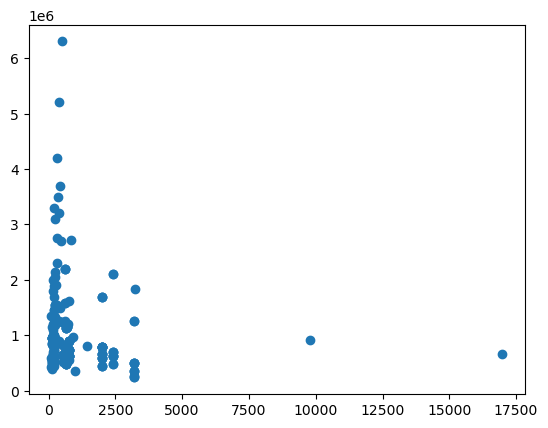

In [39]:
area = df2['Area'].to_numpy()
price = df2['Price'].to_numpy()
plt.scatter(area[:200],price[:200])

In [40]:
df2 = df2[~(df2['Property Type'] == 'Residential Land')]


In [41]:

# df2.to_csv('bayut_listings_cleaned.csv',index=False)

